Updated Notebook -> https://colab.research.google.com/drive/1WH8Btq1DQxYTPXvaQHlAA3OnruURuJCW?usp=sharing

In [1]:
#@title Import Library

# Library yang sering digunakan
import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq

# Libraries untuk pemrosesan data gambar
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

# Libraries untuk pembangunan model
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
print(tf.__version__)

2.19.0


# Data Loading

In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"defandayeremia","key":"e180686ea4d8ee7f524d3ae095591c74"}'}

In [4]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets download -d tawsifurrahman/tuberculosis-tb-chest-xray-dataset

Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset
License(s): copyright-authors
100% 663M/663M [00:02<00:00, 268MB/s]



In [6]:
!unzip tuberculosis-tb-chest-xray-dataset.zip

Archive:  tuberculosis-tb-chest-xray-dataset.zip
  inflating: TB_Chest_Radiography_Database/Normal.metadata.xlsx  
  inflating: TB_Chest_Radiography_Database/Normal/Normal-1.png  
  inflating: TB_Chest_Radiography_Database/Normal/Normal-10.png  
  inflating: TB_Chest_Radiography_Database/Normal/Normal-100.png  
  inflating: TB_Chest_Radiography_Database/Normal/Normal-1000.png  
  inflating: TB_Chest_Radiography_Database/Normal/Normal-1001.png  
  inflating: TB_Chest_Radiography_Database/Normal/Normal-1002.png  
  inflating: TB_Chest_Radiography_Database/Normal/Normal-1003.png  
  inflating: TB_Chest_Radiography_Database/Normal/Normal-1004.png  
  inflating: TB_Chest_Radiography_Database/Normal/Normal-1005.png  
  inflating: TB_Chest_Radiography_Database/Normal/Normal-1006.png  
  inflating: TB_Chest_Radiography_Database/Normal/Normal-1007.png  
  inflating: TB_Chest_Radiography_Database/Normal/Normal-1008.png  
  inflating: TB_Chest_Radiography_Database/Normal/Normal-1009.png  
  infla

In [7]:
import os
import shutil

# Plot Distribution

In [8]:
base_path = '/content/TB_Chest_Radiography_Database'
categories = ['Normal', 'Tuberculosis']

def check_dataset(path, categories):
    print("--- Dataset Checking ---")
    total_images = 0
    for cat in categories:
        folder_path = os.path.join(path, cat)
        if os.path.exists(folder_path):
            files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            print(f"Kelas {cat}: {len(files)} gambar")
            total_images += len(files)
        else:
            print(f"Peringatan: Folder {cat} tidak ditemukan!")
    print(f"Total gambar keseluruhan: {total_images}\n")

check_dataset(base_path, categories)

--- Dataset Checking ---
Kelas Normal: 3500 gambar
Kelas Tuberculosis: 700 gambar
Total gambar keseluruhan: 4200



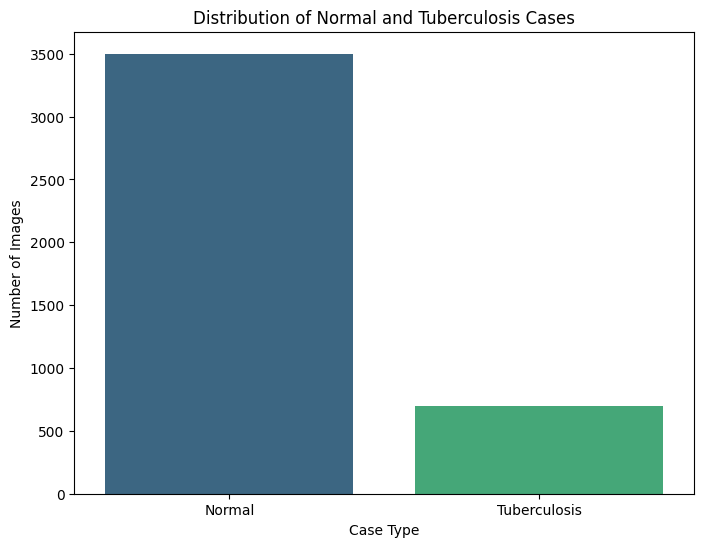

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
category_counts = {}
for cat in categories:
    folder_path = os.path.join(base_path, cat)
    if os.path.exists(folder_path):
        files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        category_counts[cat] = len(files)

df_counts = pd.DataFrame(list(category_counts.items()), columns=['Category', 'Count'])

# Create the bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x='Category', y='Count', data=df_counts, palette='viridis')
plt.title('Distribution of Normal and Tuberculosis Cases')
plt.xlabel('Case Type')
plt.ylabel('Number of Images')
plt.show()

# Dataset Checking

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os

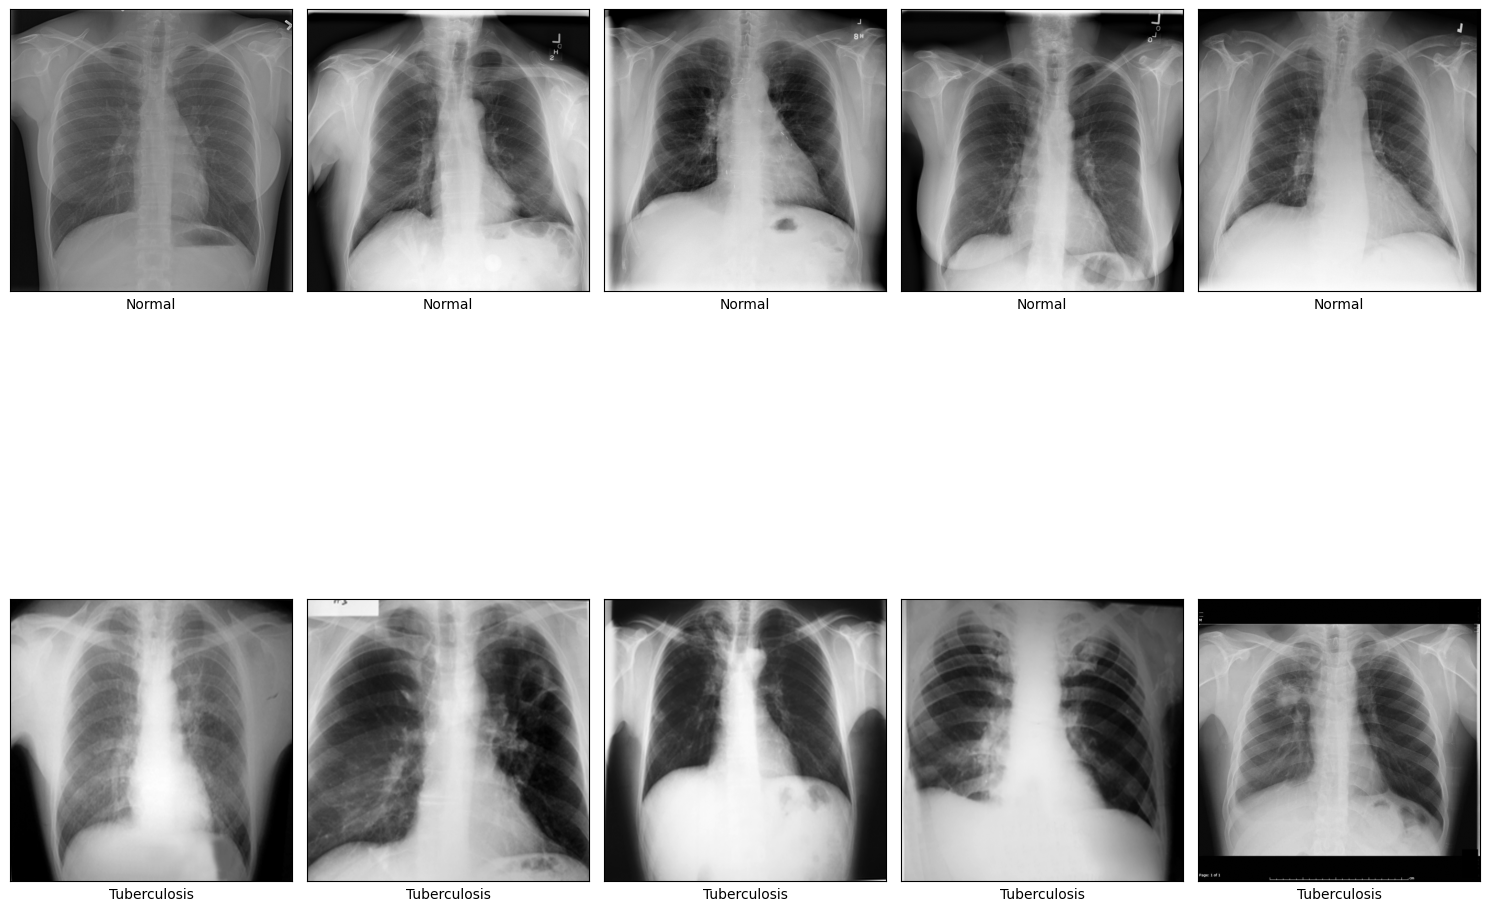

In [11]:
# Membuat kamus yang menyimpan gambar untuk setiap kelas dalam data
lung_image = {}

# Tentukan path sumber dataset
path_sub = base_path
for i in categories:
    lung_image[i] = [f for f in os.listdir(os.path.join(path_sub, i)) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# Menampilkan secara acak 5 gambar di bawah setiap dari 2 kelas dari data.
# Anda akan melihat gambar yang berbeda setiap kali kode ini dijalankan.

# Menampilkan secara acak 5 gambar di bawah setiap kelas
fig, axs = plt.subplots(len(categories), 5, figsize=(15, 15))

for i, class_name in enumerate(categories):
    # Ensure we don't try to pick more images than available
    num_images_to_display = min(5, len(lung_image[class_name]))
    images = np.random.choice(lung_image[class_name], num_images_to_display, replace=False)

    for j, image_name in enumerate(images):
        img_path = os.path.join(path_sub, class_name, image_name)
        img = Image.open(img_path).convert('L')  # Konversi menjadi skala keabuan
        axs[i, j].imshow(img, cmap='gray')
        axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])

# Fill remaining subplots if fewer than 5 images were displayed for a category
    for j in range(num_images_to_display, 5):
        axs[i, j].axis('off')

fig.tight_layout()
plt.show()

# Data Splitting

In [12]:
!pip install split-folders

In [13]:
import splitfolders

# Input: Folder asli, Output: Folder hasil split
# Rasio: 80% Train, 10% Validation, 10% Test
splitfolders.ratio("/content/TB_Chest_Radiography_Database",
                   output="/content/dataset_split",
                   seed=42,
                   ratio=(.8, .1, .1),
                   group_prefix=None,
                   move=False)

Copying files: 4200 files [00:03, 1152.06 files/s]


# Data Preprocessing & Augmentation

In [14]:
# Define image dimensions
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Define paths for the split dataset
train_dir = '/content/dataset_split/train'
val_dir = '/content/dataset_split/val'
test_dir = '/content/dataset_split/test'

# Data Augmentation and Preprocessing for Training Data
train_datagen = ImageDataGenerator(
    rescale=1./255,                 # Normalize pixel values to [0, 1]
    rotation_range=15,              # Rotate images by a small amount (up to 15 degrees)
    horizontal_flip=True,           # Randomly flip images horizontally
    brightness_range=[0.8, 1.2],    # Adjust brightness randomly
    fill_mode='nearest'             # Fill in new pixels created by rotation or shifts
)

# Preprocessing for Validation and Test Data (only rescaling)
val_test_datagen = ImageDataGenerator(
    rescale=1./255                  # Normalize pixel values to [0, 1]
)

print("Data generators initialized.")

Data generators initialized.


In [15]:
# Flow images from directories
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',            # 'binary' for 2 classes (Normal, Tuberculosis)
    shuffle=True
)

validation_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',            # 'binary' for 2 classes (Normal, Tuberculosis)
    shuffle=False                   # No need to shuffle validation data
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',            # 'binary' for 2 classes (Normal, Tuberculosis)
    shuffle=False                   # No need to shuffle test data
)

print("Train, validation, and test data generators created.")

Found 3360 images belonging to 2 classes.
Found 420 images belonging to 2 classes.
Found 420 images belonging to 2 classes.
Train, validation, and test data generators created.


The `ImageDataGenerator` for training (`train_datagen`) is configured to apply horizontal flips, small rotations (up to 15 degrees), and brightness adjustments, in addition to resizing and normalization. This helps in augmenting the dataset, particularly benefiting the minority class. The `val_test_datagen` only performs resizing and normalization, ensuring that the validation and test data reflect real-world, unaugmented images.

Now, let's verify the class indices and the number of images per class.

In [16]:
# Verify class indices and number of images
print("Class indices:", train_generator.class_indices)
print("Number of images in training set:", train_generator.samples)
print("Number of images in validation set:", validation_generator.samples)
print("Number of images in test set:", test_generator.samples)

Class indices: {'Normal': 0, 'Tuberculosis': 1}
Number of images in training set: 3360
Number of images in validation set: 420
Number of images in test set: 420


# Modeling

In [17]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Load the MobileNetV2 model pre-trained on ImageNet, excluding the top classification layer
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification layers on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x) # 1 neuron for binary classification (Normal/Tuberculosis)

model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

model.summary()
print("MobileNetV2 transfer learning model architecture prepared.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,586,177 (9.87 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

MobileNetV2 transfer learning model architecture prepared.


### Calculate Class Weights

Given the imbalance in our dataset (3500 Normal vs. 700 Tuberculosis images), calculating class weights is crucial. This assigns a higher penalty to misclassifications of the minority class ('Tuberculosis'), encouraging the model to pay more attention to it during training. This makes the model more fair in detecting Tuberculosis.

In [18]:
from sklearn.utils import class_weight

# Get class labels from the training generator
labels = train_generator.classes

# Get the unique classes and their counts
classes = np.unique(labels)

# Calculate class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=labels
)

class_weights_dict = dict(zip(classes, class_weights))

print("Calculated Class Weights:", class_weights_dict)

Calculated Class Weights: {np.int32(0): np.float64(0.6), np.int32(1): np.float64(3.0)}


### Model Training Implementation

Now we will train the MobileNetV2 model using the `train_generator` and `validation_generator`. We will incorporate the calculated `class_weights` and use several Keras callbacks to improve training stability and performance:

*   **ModelCheckpoint**: Saves the best model based on validation accuracy.
*   **EarlyStopping**: Stops training if validation loss doesn't improve for a certain number of epochs, preventing overfitting.
*   **ReduceLROnPlateau**: Reduces the learning rate if validation loss plateaus, helping the model escape local minima.

In [19]:
# Define callbacks
checkpoint = ModelCheckpoint(
    'best_mobilenetv2_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

callbacks = [checkpoint, early_stopping, reduce_lr]

# Train the model
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    class_weight=class_weights_dict,
    callbacks=callbacks,
    verbose=1
)

print("Model training complete.")

Epoch 1/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - accuracy: 0.7476 - loss: 0.5239
Epoch 1: val_accuracy improved from None to 0.98333, saving model to best_mobilenetv2_model.keras

Epoch 1: finished saving model to best_mobilenetv2_model.keras
105/105 ━━━━━━━━━━━━━━━━━━━━ 108s 840ms/step - accuracy: 0.8607 - loss: 0.3380 - val_accuracy: 0.9833 - val_loss: 0.0726 - learning_rate: 1.0000e-04
Epoch 2/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 637ms/step - accuracy: 0.9441 - loss: 0.1644
Epoch 2: val_accuracy improved from 0.98333 to 0.99286, saving model to best_mobilenetv2_model.keras

Epoch 2: finished saving model to best_mobilenetv2_model.keras
105/105 ━━━━━━━━━━━━━━━━━━━━ 71s 679ms/step - accuracy: 0.9568 - loss: 0.1319 - val_accuracy: 0.9929 - val_loss: 0.0420 - learning_rate: 1.0000e-04
Epoch 3/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 625ms/step - accuracy: 0.9730 - loss: 0.0875
Epoch 3: val_accuracy did not improve from 0.99286
105/105 ━━━━━━━━━━━━━━━━━━━━ 69s 658ms/step - accuracy: 0.976

# Model Evaluation

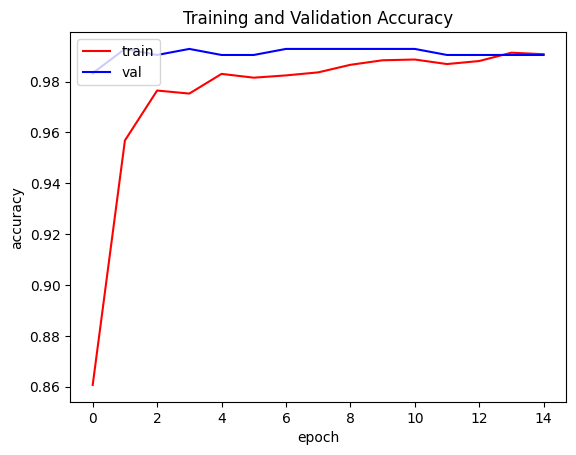

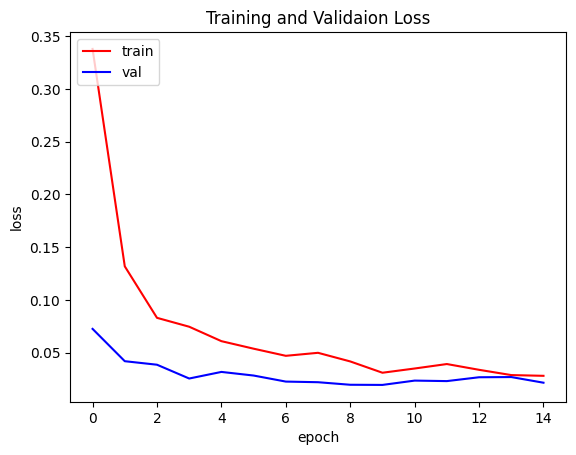

In [20]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r')
plt.plot(epochs, val_acc, 'b')
plt.title('Training and Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(epochs, loss, 'r')
plt.plot(epochs, val_loss, 'b')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.title('Training and Validaion Loss')
plt.show()



              precision    recall  f1-score   support

      Normal     0.9915    1.0000    0.9957       350
          TB     1.0000    0.9571    0.9781        70

    accuracy                         0.9929       420
   macro avg     0.9958    0.9786    0.9869       420
weighted avg     0.9929    0.9929    0.9928       420



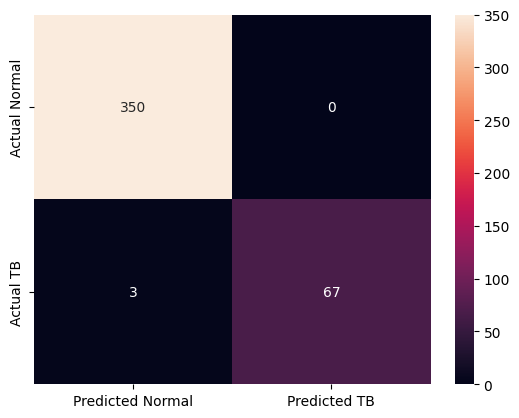

In [27]:
test_generator.reset()

predictions = model.predict(test_generator,verbose=0)
predictions = predictions.copy()
predictions[predictions <= 0.5] = 0
predictions[predictions > 0.5] = 1
predictions = predictions.astype(int) # Ensure predictions are integers

# Print Confusion Matrix
cm = pd.DataFrame(data=confusion_matrix(test_generator.classes, predictions, labels=[0, 1]),index=["Actual Normal", "Actual TB"],
columns=["Predicted Normal", "Predicted TB"])
sns.heatmap(cm,annot=True,fmt="d")

# Print Classification Report
print("\n")
print(classification_report(y_true=test_generator.classes,y_pred=predictions,target_names =['Normal','TB'], digits=4))